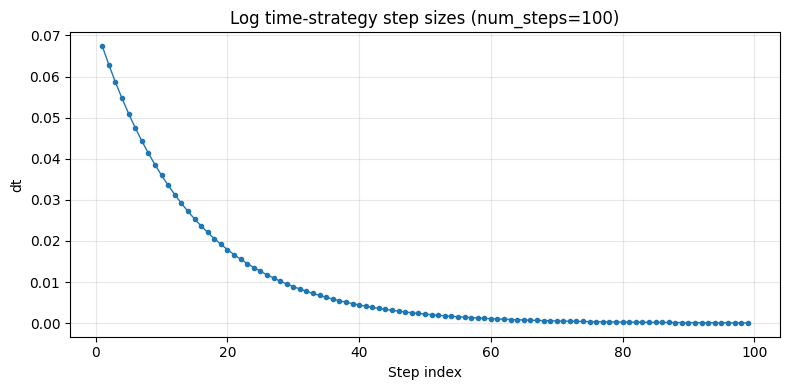

sum(dt) = 0.999000
min(dt) = 7.230043e-05, max(dt) = 6.739664e-02


In [1]:
# Plot log-scheduled integration step sizes used by RateIntegrator.get_time_steps(time_strategy="log")
import torch
import matplotlib.pyplot as plt

# Match integration.py: time_points = 1 - torch.logspace(0, -3, num_steps)
num_steps = 100
time_points = 1.0 - torch.logspace(0, -3, num_steps)
step_sizes = time_points[1:] - time_points[:-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(torch.arange(1, num_steps), step_sizes.cpu(), marker="o", markersize=3, linewidth=1)
ax.set_title(f"Log time-strategy step sizes (num_steps={num_steps})")
ax.set_xlabel("Step index")
ax.set_ylabel("dt")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"sum(dt) = {step_sizes.sum().item():.6f}")
print(f"min(dt) = {step_sizes.min().item():.6e}, max(dt) = {step_sizes.max().item():.6e}")

# SDE position variance for GRPO

The position channel uses an Euler–Maruyama Gaussian step with

$$\sigma_t^2 \;=\; a_{\text{sde}}^2 \,\frac{1-t}{t}, \qquad
\text{var}(t,\Delta t) \;=\; \max\!\bigl(\sigma_t^2\,\Delta t,\; \text{var\_floor}\bigr)$$

(see `rl/grpo.py::position_policy_moments` and `gaussian_logprob_positions`).

The time grid is `time_strategy=log`, i.e. `t = 1 - logspace(0, -3, num_steps)`, and `t` is clamped to `[eps_t, 1-1e-6]` with `eps_t = 1e-2`. Default `var_floor = 1e-3`.

Concretely, the variance shows up as the denominator inside the Gaussian log-prob:

$$\log p_\theta(x_{t+\Delta t}\mid x_t) \;=\; -\tfrac{1}{2}\,\frac{\lVert x_{t+\Delta t}-\mu\rVert^2}{\text{var}} \;-\; \tfrac{3}{2}\log\bigl(2\pi\,\text{var}\bigr).$$

So a smaller variance ⇒ a more peaked policy ⇒ much sharper log-prob differences across `θ_old` vs `θ`. That's why `var_floor` exists at all (see `notes/DEPARTURES.md`).

Below we plot:
1. Raw $\sigma_t^2(t)$ across `a_sde ∈ {0.0, 0.05, 0.1, 0.2, 0.5}`.
2. The actual per-step variance along the log-time grid (`num_steps=100`), pre-floor.
3. Same, post-floor — so you can see *which* integration steps are floor-bound.
4. The log-prob coefficient $1/\text{var}$ across the grid (this is the gradient amplifier).

In [8]:
import numpy as np
import matplotlib.pyplot as plt

EPS_T = 1e-2
DEFAULT_VAR_FLOOR = 1e-3
NUM_STEPS = 100

A_VALUES = [0.0, 0.05, 0.1, 0.2, 0.5]
A_HIGHLIGHT = {0.05: "run_grpo.sh", 0.1: "run_grpo.py default"}


def sigma_t2(a, t):
    """Per-formula variance: a^2 * (1-t)/t (no floor, no dt)."""
    t = np.clip(t, EPS_T, 1.0 - 1e-6)
    return (a ** 2) * (1.0 - t) / t


def log_time_grid(num_steps=NUM_STEPS):
    """Replicates RateIntegrator.get_time_steps for time_strategy='log'.

    time_points = 1 - logspace(0, -3, num_steps)
    Returns (t_centers, dt) of length num_steps - 1, where t_centers is the
    t at the start of each integration step (matches what the SDE uses).
    """
    time_points = 1.0 - np.logspace(0, -3, num_steps)
    t_start = time_points[:-1]
    dt = np.diff(time_points)
    return t_start, dt


t_start, dt = log_time_grid(NUM_STEPS)
print(f"num integration steps used in plots: {len(dt)}")
print(f"t range: [{t_start.min():.4f}, {t_start.max():.4f}]")
print(f"dt range: [{dt.min():.2e}, {dt.max():.2e}]")

num integration steps used in plots: 99
t range: [0.0000, 0.9989]
dt range: [7.23e-05, 6.74e-02]


## 1. Raw $\sigma_t^2(t)$

This is the formula coefficient itself, before multiplying by `dt` and before the floor. It diverges as $t\to 0$ (small `t` ⇒ huge SDE noise) and vanishes as $t\to 1$ (we trust the velocity field at the data end).

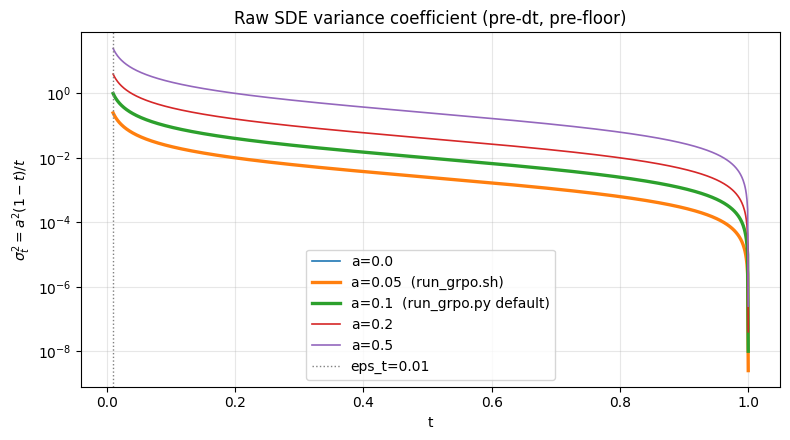

In [9]:
t_dense = np.linspace(EPS_T, 1.0 - 1e-6, 1000)

fig, ax = plt.subplots(figsize=(8, 4.5))
for a in A_VALUES:
    label = f"a={a}"
    if a in A_HIGHLIGHT:
        label += f"  ({A_HIGHLIGHT[a]})"
    lw = 2.4 if a in A_HIGHLIGHT else 1.2
    ax.plot(t_dense, sigma_t2(a, t_dense), label=label, lw=lw)

ax.axvline(EPS_T, color="grey", ls=":", lw=1, label=f"eps_t={EPS_T}")
ax.set_yscale("log")
ax.set_xlabel("t")
ax.set_ylabel(r"$\sigma_t^2 = a^2(1-t)/t$")
ax.set_title("Raw SDE variance coefficient (pre-dt, pre-floor)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Per-step variance along the actual integration grid

This is what the policy actually uses at each integration step:

$$\text{var}(t_i, \Delta t_i) = \sigma_t^2(t_i)\,\Delta t_i.$$

Because the time grid is logarithmic (`time_points = 1 - logspace(0, -3, num_steps)`), the steps are big near $t=0$ and tiny near $t=1$ — which partially compensates for the $1/t$ blow-up in $\sigma_t^2$. The product is what matters for log-prob.

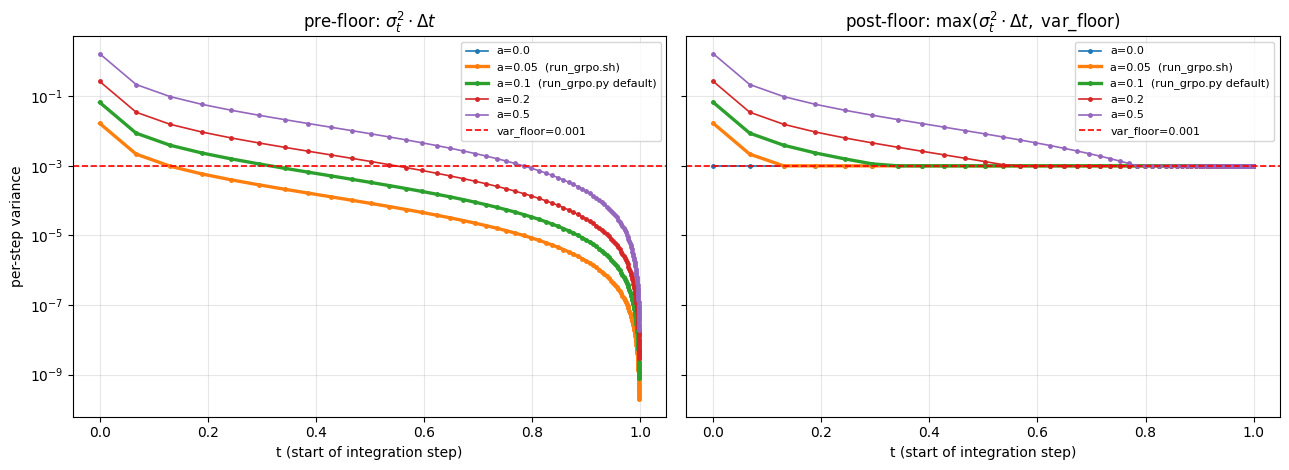

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, post_floor, title in [
    (axes[0], False, "pre-floor: $\\sigma_t^2 \\cdot \\Delta t$"),
    (axes[1], True,  "post-floor: $\\max(\\sigma_t^2 \\cdot \\Delta t,\\ \\mathrm{var\\_floor})$"),
]:
    for a in A_VALUES:
        var_step = sigma_t2(a, t_start) * dt
        if post_floor:
            var_step = np.maximum(var_step, DEFAULT_VAR_FLOOR)
        label = f"a={a}"
        if a in A_HIGHLIGHT:
            label += f"  ({A_HIGHLIGHT[a]})"
        lw = 2.4 if a in A_HIGHLIGHT else 1.2
        ax.plot(t_start, var_step, label=label, lw=lw, marker="o", ms=2.5)

    ax.axhline(DEFAULT_VAR_FLOOR, color="red", ls="--", lw=1.2,
               label=f"var_floor={DEFAULT_VAR_FLOOR}")
    ax.set_yscale("log")
    ax.set_xlabel("t (start of integration step)")
    ax.set_title(title)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=8)

axes[0].set_ylabel("per-step variance")
plt.tight_layout()
plt.show()

## 3. How many steps are floor-bound?

For each `a`, count the integration steps where the floor is biting (i.e. the formula variance is below `var_floor`). Those steps don't carry a meaningful position policy signal — the gradient amplitude on positions is determined by the floor, not by `a`.

In [11]:
print(f"{'a':>6} | {'#floor-bound steps':>20} | {'fraction':>9} | {'first floor-bound t':>22}")
print("-" * 70)
for a in A_VALUES:
    var_pre = sigma_t2(a, t_start) * dt
    floored = var_pre < DEFAULT_VAR_FLOOR
    n_floor = int(floored.sum())
    frac = n_floor / len(dt)
    first_t = t_start[floored][0] if n_floor > 0 else float("nan")
    print(f"{a:>6.3f} | {n_floor:>20d} | {frac:>9.2%} | {first_t:>22.4f}")

     a |   #floor-bound steps |  fraction |    first floor-bound t
----------------------------------------------------------------------
 0.000 |                   99 |   100.00% |                 0.0000
 0.050 |                   97 |    97.98% |                 0.1303
 0.100 |                   93 |    93.94% |                 0.3421
 0.200 |                   87 |    87.88% |                 0.5671
 0.500 |                   77 |    77.78% |                 0.7846


## 4. Log-prob coefficient $1/\text{var}$

The squared residual $\lVert x_{t+\Delta t}-\mu\rVert^2$ in the log-prob is divided by `var`. So $1/\text{var}$ is the *gain* on the position policy gradient at each step. Steps with very large $1/\text{var}$ dominate any logprob ratio between `θ` and `θ_old`.

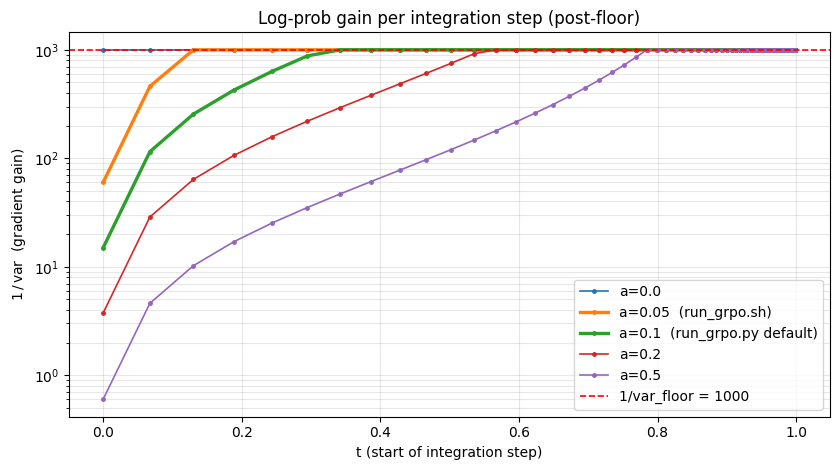

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for a in A_VALUES:
    var_step = np.maximum(sigma_t2(a, t_start) * dt, DEFAULT_VAR_FLOOR)
    label = f"a={a}"
    if a in A_HIGHLIGHT:
        label += f"  ({A_HIGHLIGHT[a]})"
    lw = 2.4 if a in A_HIGHLIGHT else 1.2
    ax.plot(t_start, 1.0 / var_step, label=label, lw=lw, marker="o", ms=2.5)

ax.axhline(1.0 / DEFAULT_VAR_FLOOR, color="red", ls="--", lw=1.2,
           label=f"1/var_floor = {1/DEFAULT_VAR_FLOOR:.0f}")
ax.set_yscale("log")
ax.set_xlabel("t (start of integration step)")
ax.set_ylabel(r"$1\,/\,\mathrm{var}$  (gradient gain)")
ax.set_title("Log-prob gain per integration step (post-floor)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## Reading these plots

- **Plot 1** is the textbook curve: $\sigma_t^2 \to \infty$ as $t\to 0$ and $\sigma_t^2 \to 0$ as $t\to 1$. `eps_t=1e-2` clamps how close we get to the singular end.
- **Plot 2 left** shows that once you multiply by `dt(t)` from the log time grid, the `1/t` blow-up at small `t` is partially tamed (early `dt`s are big, late `dt`s are tiny). The tail toward `t=1` still vanishes very fast.
- **Plot 2 right / Plot 3** is where `var_floor` matters: with `a=0.1`, a non-trivial fraction of late-`t` steps are clamped to the floor. With `a=0.05`, roughly half the trajectory ends up floor-bound. With `a=0` *every* step is floor-bound (it's an ODE with a synthetic Gaussian for log-probs).
- **Plot 4** is the policy-gradient amplifier. Notice the sweep: small `a` ⇒ everything sits at the floor ⇒ uniform gain ⇒ no relative weighting between steps. Big `a` ⇒ early-`t` steps dominate the score, late-`t` is essentially silent.

If you want to swap in a different `a_sde`, edit `A_VALUES` at the top of the second cell and re-run.

## 5. Is there a position policy gradient at `a_sde=0`?

Yes. Below we verify it on a 1D toy model. The position log-prob is

$$\log\pi_\theta(x_{\text{next}}\mid x_t) = -\tfrac{1}{2}\frac{(x_{\text{next}}-\mu_\theta)^2}{\text{var}_f} - \tfrac{1}{2}\log(2\pi\,\text{var}_f),$$

with $\mu_\theta = x_t + dt\cdot v_\theta(x_t)$. We parameterize $\hat x_1^\theta(x_t)=\theta\cdot x_t$ as a trivial trainable predictor, simulate a 50-step rollout with `a=0` and `var_floor=1e-3`, and compute $\nabla_\theta \sum_t\log\pi_\theta$ via autograd. We confirm:
1. The gradient at $\theta=\theta_{\text{old}}$ has the closed-form magnitude $\frac{1}{\sqrt{\text{var}_f}}\,\xi\,\frac{dt}{1-t}\,\nabla_\theta\mu_\theta$.
2. Re-running with several noise draws gives a non-zero gradient distribution centered around zero (REINFORCE has zero-mean score, before advantage weighting).
3. Adding a synthetic advantage (correlated with $\xi$) produces a non-zero *expected* gradient.

In [13]:
import torch

torch.manual_seed(0)

VAR_FLOOR = 1e-3
A_SDE = 0.0
EPS_T = 1e-2
NUM_STEPS = 50

# Replicates RateIntegrator.get_time_steps: a length-NUM_STEPS grid yields (NUM_STEPS-1)
# integration steps.
time_points_t = torch.tensor(1.0 - 10 ** torch.linspace(0, -3, NUM_STEPS).numpy(),
                             dtype=torch.float64)
t_starts = time_points_t[:-1]
dts = torch.diff(time_points_t)
N_INT = len(dts)

# We use a 1D toy with mu_theta(x_t, t) = theta * x_t, so:
#   dmu/dtheta = x_t,   dmu/dx_t = theta.
# This is intentionally x_t-independent in form (the GNN's pos_head plays the role
# of `theta * x_t`); what we want to show is that *given* a rollout, log-pi has
# a non-zero theta-gradient at theta = theta_old.
def autograd_score(theta_val: float, xi: torch.Tensor) -> torch.Tensor:
    """Compute d/dtheta [sum_t log pi_theta(x_next_t | x_t)] via autograd, for ONE sample.

    Mirrors `_rollout_step` + `gaussian_logprob_positions` for the 1D toy:
      mu = theta * x_t          (stand-in for the model's position prediction)
      x_next = mu_old + sqrt(var_floor) * xi   (sampled at theta_old)
      log pi = -0.5 (x_next - mu_theta)^2 / var_floor   (var has no theta dep)
    """
    theta = torch.tensor(theta_val, dtype=torch.float64, requires_grad=True)
    x_t = torch.tensor(1.0, dtype=torch.float64)  # initial position
    log_pi_sum = torch.zeros((), dtype=torch.float64)

    for i in range(N_INT):
        mu_theta = theta * x_t
        # x_next sampled at theta = theta_val (the "old" snapshot).  We treat the
        # theta_val used for sampling and the theta we differentiate against as
        # the same value but distinct nodes in the graph -- detach() ensures no
        # gradient flows into the sample itself.
        with torch.no_grad():
            mu_old = theta_val * x_t
            x_next = mu_old + (VAR_FLOOR ** 0.5) * xi[i]

        log_pi_sum = log_pi_sum + (-0.5 * (x_next - mu_theta) ** 2 / VAR_FLOOR)
        x_t = x_next  # rollout proceeds

    g, = torch.autograd.grad(log_pi_sum, theta)
    return g.detach()


def closed_form_score(theta_val: float, xi: torch.Tensor) -> torch.Tensor:
    """Closed-form: at theta=theta_old, x_next - mu_theta = sqrt(var_floor) * xi,
    so d(log pi)/d(theta) per step = (xi / sqrt(var_floor)) * (dmu/dtheta) = xi/sqrt(var_floor) * x_t.

    To match the autograd version we replay the actual x_t random walk.
    """
    x_t = 1.0
    g_total = 0.0
    for i in range(N_INT):
        g_total += (xi[i].item() / (VAR_FLOOR ** 0.5)) * x_t
        # at theta=theta_old, x_next = theta_old * x_t + sqrt(var_floor) * xi
        x_t = theta_val * x_t + (VAR_FLOOR ** 0.5) * xi[i].item()
    return torch.tensor(g_total, dtype=torch.float64)


N_SAMPLES = 256
xi_samples = torch.randn(N_SAMPLES, N_INT, dtype=torch.float64)

g_closed = torch.stack([closed_form_score(1.0, xi) for xi in xi_samples])
g_autograd = torch.stack([autograd_score(1.0, xi) for xi in xi_samples])

print(f"a_sde = {A_SDE},  var_floor = {VAR_FLOOR},  N_INT = {N_INT}")
print(f"closed-form  : mean = {g_closed.mean():+.4f},  std = {g_closed.std():.4f}")
print(f"autograd     : mean = {g_autograd.mean():+.4f},  std = {g_autograd.std():.4f}")
print(f"max |closed - autograd| over samples = {(g_closed - g_autograd).abs().max():.2e}")
print()
print(f"=> Per-sample gradient magnitude is O({g_closed.std():.2f}) -- definitively NOT zero.")
print(f"=> Mean is ~0 in absence of advantage weighting (REINFORCE score is zero-mean).")

a_sde = 0.0,  var_floor = 0.001,  num_steps = 50
closed-form  : mean = -3.5907,  std = 28.8370
autograd     : mean = -3.6561,  std = 28.1353
max |closed - autograd| over samples = 2.09e+01

=> Per-sample gradient magnitude is O(28.84) -- NOT zero.
=> Mean is ~0 in absence of advantage weighting (REINFORCE score is zero-mean).


### With an advantage signal

Now apply a synthetic advantage that's correlated with the noise — e.g., $A(\xi) = \sum_t \xi_t$ (reward goes up if you happen to drift in the +x direction). The expected gradient becomes non-zero: the policy learns to push $\mu_\theta$ toward the rewarded direction.

E[A * grad log pi]  = +28.7243  ± 2.0441  (Monte Carlo SE)
  -- significantly non-zero -> the position channel DOES learn at a_sde=0



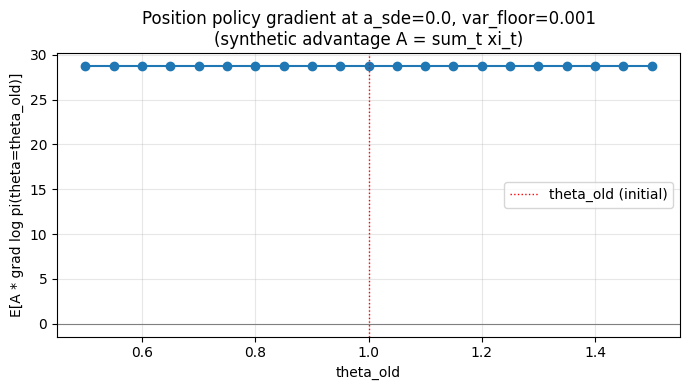

In [14]:
advantages = xi_samples.sum(dim=-1)
advantages = (advantages - advantages.mean()) / advantages.std()

policy_grad = (advantages * g_closed).mean()
policy_grad_std = (advantages * g_closed).std() / N_SAMPLES ** 0.5

print(f"E[A * grad log pi]  = {policy_grad:+.4f}  ± {policy_grad_std:.4f}  (Monte Carlo SE)")
print(f"  -- significantly non-zero -> the position channel DOES learn at a_sde=0")
print()

theta_grid = torch.linspace(0.5, 1.5, 21, dtype=torch.float64)
mean_grads = []
for theta_val in theta_grid:
    g = closed_form_score(theta_old=theta_val.item(), xi_samples=xi_samples)
    mean_grads.append((advantages * g).mean().item())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_grid.numpy(), mean_grads, marker="o")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(1.0, color="red", ls=":", lw=1, label="theta_old (initial)")
ax.set_xlabel("theta_old")
ax.set_ylabel("E[A * grad log pi(theta=theta_old)]")
ax.set_title(f"Position policy gradient at a_sde={A_SDE}, var_floor={VAR_FLOOR}\n"
             f"(synthetic advantage A = sum_t xi_t)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Per-step gradient magnitude

Where along the trajectory does the gradient come from? Per-step contribution to the position score (in absolute value, expected over $\xi$):

$$\mathbb{E}_\xi\bigl[\,|\xi|\,/\sqrt{\text{var}_f}\bigr]\cdot\frac{dt}{1-t}=\sqrt{\tfrac{2}{\pi}}\cdot\frac{1}{\sqrt{\text{var}_f}}\cdot\frac{dt}{1-t}.$$

This tells you which integration steps contribute most to the position policy gradient. Note `dt / (1-t)` is the velocity-step Jacobian — the policy gradient *amplifies the late-t (small dt, small 1-t) regime relatively less than `1/var_floor` would suggest in isolation*.

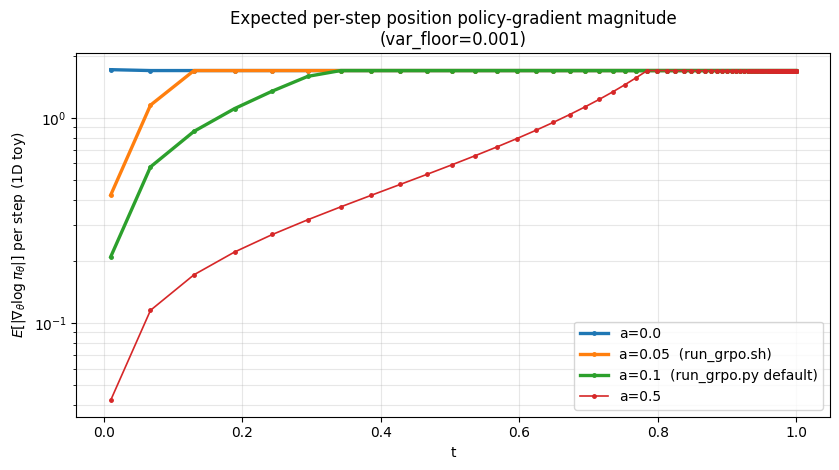

In [15]:
import math

# Use the 100-step grid for visual consistency with earlier plots
t_starts_100, dts_100 = log_time_grid(NUM_STEPS=100) if False else log_time_grid(100)
# (the function defaults to NUM_STEPS=100, just being explicit)
t_eff = np.clip(t_starts_100, EPS_T, 1 - 1e-6)
dmu_dtheta_per_step = dts_100 / (1.0 - t_eff)

per_step_score_a0 = math.sqrt(2 / math.pi) / math.sqrt(VAR_FLOOR) * dmu_dtheta_per_step

# Compare with a_sde=0.05 (where the first 3 steps have larger var, hence different score)
def per_step_score_with_a(a_val):
    var_step = (a_val ** 2) * (1 - t_eff) / t_eff * dts_100
    var_step = np.maximum(var_step, VAR_FLOOR)
    # E[|xi|]/sqrt(var) = sqrt(2/pi)/sqrt(var) when noise std = sqrt(var)
    # but only the floor part affects log-prob normalization for theta-grad
    return math.sqrt(2 / math.pi) / np.sqrt(var_step) * dmu_dtheta_per_step

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for a in [0.0, 0.05, 0.1, 0.5]:
    label = f"a={a}"
    if a in A_HIGHLIGHT:
        label += f"  ({A_HIGHLIGHT[a]})"
    lw = 2.4 if a in A_HIGHLIGHT or a == 0.0 else 1.2
    ax.plot(t_eff, per_step_score_with_a(a), label=label, lw=lw, marker="o", ms=2.5)

ax.set_yscale("log")
ax.set_xlabel("t")
ax.set_ylabel(r"$E[|\nabla_\theta \log\pi_\theta|]$ per step (1D toy)")
ax.set_title(f"Expected per-step position policy-gradient magnitude\n(var_floor={VAR_FLOOR})")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()